#**Hadoop MapReduce- WordCount**

1. Environment Setup and Configuration

2. Cluster Configuration

3. Cluster Initialization and Daemon Startup

4. Data Extraction and Preprocessing

5. Standalone Mode Configuration

6. Job Execution and Result Verification

7. MapReduce Logic Simulation and Visualization

##**STEP 1 — Environment Setup and Configuration**




In [1]:
%%bash
javac -version
java -version


javac 17.0.17


openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)


In [2]:
%%bash
wget https://downloads.apache.org/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz


--2026-01-10 18:31:59--  https://downloads.apache.org/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz
Resolving downloads.apache.org (downloads.apache.org)... 135.181.214.104, 88.99.208.237, 2a01:4f8:10a:39da::2, ...
Connecting to downloads.apache.org (downloads.apache.org)|135.181.214.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 730107476 (696M) [application/x-gzip]
Saving to: ‘hadoop-3.3.6.tar.gz’

     0K .......... .......... .......... .......... ..........  0%  197K 60m19s
    50K .......... .......... .......... .......... ..........  0%  395K 45m12s
   100K .......... .......... .......... .......... ..........  0% 20.7M 30m19s
   150K .......... .......... .......... .......... ..........  0% 22.0M 22m52s
   200K .......... .......... .......... .......... ..........  0%  404K 24m10s
   250K .......... .......... .......... .......... ..........  0% 19.3M 20m15s
   300K .......... .......... .......... .......... ..........  0% 19.2M 17m26s
   3

In [3]:
%%bash
tar -xvzf hadoop-3.3.6.tar.gz


hadoop-3.3.6/
hadoop-3.3.6/NOTICE-binary
hadoop-3.3.6/licenses-binary/
hadoop-3.3.6/licenses-binary/LICENSE-lz4.txt
hadoop-3.3.6/licenses-binary/LICENSE-zstd-jni.txt
hadoop-3.3.6/licenses-binary/LICENSE-tree.txt
hadoop-3.3.6/licenses-binary/LICENSE-azure-cosmosdb.txt
hadoop-3.3.6/licenses-binary/LICENSE-moment.txt
hadoop-3.3.6/licenses-binary/LICENSE-jline.txt
hadoop-3.3.6/licenses-binary/LICENSE-hsql.txt
hadoop-3.3.6/licenses-binary/LICENSE-junit.txt
hadoop-3.3.6/licenses-binary/LICENSE-ojalgo.txt
hadoop-3.3.6/licenses-binary/LICENSE-paranamer.txt
hadoop-3.3.6/licenses-binary/LICENSE-freebsd.txt
hadoop-3.3.6/licenses-binary/LICENSE-jakarta.xml.bind-api.txt
hadoop-3.3.6/licenses-binary/LICENSE-bloomfilter.txt
hadoop-3.3.6/licenses-binary/LICENSE-d3.txt
hadoop-3.3.6/licenses-binary/LICENSE-jaf.txt
hadoop-3.3.6/licenses-binary/LICENSE-dust.txt
hadoop-3.3.6/licenses-binary/LICENSE-jdom.txt
hadoop-3.3.6/licenses-binary/LICENSE-datatables.txt
hadoop-3.3.6/licenses-binary/LICENSE-azure-data-

In [4]:
!ls


hadoop-3.3.6  hadoop-3.3.6.tar.gz  sample_data


In [5]:
!readlink -f $(which java)


/usr/lib/jvm/java-17-openjdk-amd64/bin/java


In [6]:
import os

os.environ["HADOOP_HOME"] = "/content/hadoop-3.3.6"
os.environ["HADOOP_CONF_DIR"] = "/content/hadoop-3.3.6/etc/hadoop"
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] += ":/content/hadoop-3.3.6/bin:/content/hadoop-3.3.6/sbin"


In [7]:
!echo $JAVA_HOME


/usr/lib/jvm/java-17-openjdk-amd64


In [8]:
!echo "HADOOP_HOME=$HADOOP_HOME"


HADOOP_HOME=/content/hadoop-3.3.6


In [9]:
!which hadoop


/content/hadoop-3.3.6/bin/hadoop


In [10]:
!chmod +x /content/hadoop-3.3.6/etc/hadoop/hadoop-env.sh


In [11]:
!chmod -R 755 /content/hadoop-3.3.6/etc/hadoop
!chmod -R 755 /content/hadoop-3.3.6/bin
!chmod -R 755 /content/hadoop-3.3.6/sbin


In [12]:
!/content/hadoop-3.3.6/etc/hadoop/hadoop-env.sh


In [13]:
!hadoop version

Hadoop 3.3.6
Source code repository https://github.com/apache/hadoop.git -r 1be78238728da9266a4f88195058f08fd012bf9c
Compiled by ubuntu on 2023-06-18T08:22Z
Compiled on platform linux-x86_64
Compiled with protoc 3.7.1
From source with checksum 5652179ad55f76cb287d9c633bb53bbd
This command was run using /content/hadoop-3.3.6/share/hadoop/common/hadoop-common-3.3.6.jar


**Prerequisite Verification:** Checking if the Java Compiler (javac) and Runtime (java) are installed, as Hadoop requires a Java environment to run.

**Software Retrieval & Extraction:** Using wget to download the Hadoop binary archive and tar to unpack the files into your local directory.

**Environment Variable Mapping:** The os.environ block defines the "Home" directories (HADOOP_HOME, JAVA_HOME) and updates the system PATH. This tells the system exactly where to look for Hadoop commands.

**Permission Provisioning:** The chmod commands grant "Execute" permissions to the scripts. Without this, the system would block Hadoop from running for security reasons.

**Installation Verification:** The final !hadoop version command is the "smoke test" to confirm the setup was successful.

##**Step2: Cluster Configuration**

In [14]:
!ls /content/hadoop-3.3.6/etc/hadoop


capacity-scheduler.xml		  kms-log4j.properties
configuration.xsl		  kms-site.xml
container-executor.cfg		  log4j.properties
core-site.xml			  mapred-env.cmd
hadoop-env.cmd			  mapred-env.sh
hadoop-env.sh			  mapred-queues.xml.template
hadoop-metrics2.properties	  mapred-site.xml
hadoop-policy.xml		  shellprofile.d
hadoop-user-functions.sh.example  ssl-client.xml.example
hdfs-rbf-site.xml		  ssl-server.xml.example
hdfs-site.xml			  user_ec_policies.xml.template
httpfs-env.sh			  workers
httpfs-log4j.properties		  yarn-env.cmd
httpfs-site.xml			  yarn-env.sh
kms-acls.xml			  yarnservice-log4j.properties
kms-env.sh			  yarn-site.xml


In [15]:
%%bash
cat > /content/hadoop-3.3.6/etc/hadoop/core-site.xml <<EOF
<configuration>
  <property>
    <name>fs.defaultFS</name>
    <value>hdfs://localhost:9000</value>
  </property>
</configuration>
EOF


In [16]:
!cat /content/hadoop-3.3.6/etc/hadoop/core-site.xml


<configuration>
  <property>
    <name>fs.defaultFS</name>
    <value>hdfs://localhost:9000</value>
  </property>
</configuration>


In [17]:
%%bash
cat > /content/hadoop-3.3.6/etc/hadoop/mapred-site.xml <<EOF
<configuration>
  <property>
    <name>mapreduce.framework.name</name>
    <value>local</value>
  </property>
</configuration>
EOF


In [18]:
!cat /content/hadoop-3.3.6/etc/hadoop/mapred-site.xml


<configuration>
  <property>
    <name>mapreduce.framework.name</name>
    <value>local</value>
  </property>
</configuration>


In [19]:
%%bash
cat > /content/hadoop-3.3.6/etc/hadoop/hdfs-site.xml <<EOF
<configuration>
  <property>
    <name>dfs.replication</name>
    <value>1</value>
  </property>

  <property>
    <name>dfs.namenode.name.dir</name>
    <value>/content/hadoopdata/namenode</value>
  </property>

  <property>
    <name>dfs.datanode.data.dir</name>
    <value>/content/hadoopdata/datanode</value>
  </property>
</configuration>
EOF


In [20]:
!cat /content/hadoop-3.3.6/etc/hadoop/hdfs-site.xml


<configuration>
  <property>
    <name>dfs.replication</name>
    <value>1</value>
  </property>

  <property>
    <name>dfs.namenode.name.dir</name>
    <value>/content/hadoopdata/namenode</value>
  </property>

  <property>
    <name>dfs.datanode.data.dir</name>
    <value>/content/hadoopdata/datanode</value>
  </property>
</configuration>


In [21]:
%%bash
cat > /content/hadoop-3.3.6/etc/hadoop/yarn-site.xml
<?xml version="1.0"?>
<configuration>

  <property>
    <name>yarn.resourcemanager.hostname</name>
    <value>localhost</value>
  </property>

  <property>
    <name>yarn.resourcemanager.address</name>
    <value>localhost:8032</value>
  </property>

  <property>
    <name>yarn.resourcemanager.scheduler.address</name>
    <value>localhost:8030</value>
  </property>

  <property>
    <name>yarn.resourcemanager.resource-tracker.address</name>
    <value>localhost:8031</value>
  </property>

  <property>
    <name>yarn.resourcemanager.admin.address</name>
    <value>localhost:8033</value>
  </property>

  <property>
    <name>yarn.nodemanager.aux-services</name>
    <value>mapreduce_shuffle</value>
  </property>

</configuration>


In [22]:
!cat /content/hadoop-3.3.6/etc/hadoop/yarn-site.xml


<?xml version="1.0"?>
<configuration>

  <property>
    <name>yarn.resourcemanager.hostname</name>
    <value>localhost</value>
  </property>

  <property>
    <name>yarn.resourcemanager.address</name>
    <value>localhost:8032</value>
  </property>

  <property>
    <name>yarn.resourcemanager.scheduler.address</name>
    <value>localhost:8030</value>
  </property>

  <property>
    <name>yarn.resourcemanager.resource-tracker.address</name>
    <value>localhost:8031</value>
  </property>

  <property>
    <name>yarn.resourcemanager.admin.address</name>
    <value>localhost:8033</value>
  </property>

  <property>
    <name>yarn.nodemanager.aux-services</name>
    <value>mapreduce_shuffle</value>
  </property>

</configuration>


In [23]:
!grep JAVA_HOME /content/hadoop-3.3.6/etc/hadoop/hadoop-env.sh


#  JAVA_HOME=/usr/java/testing hdfs dfs -ls
# Technically, the only required environment variable is JAVA_HOME.
# export JAVA_HOME=


**1. core-site.xml:**

  Core System Setup
This file tells Hadoop where the NameNode (the master directory) lives.
**Key setting:** fs.defaultFS set to hdfs://localhost:9000.
**Purpose:** It defines the default file system URI and the port used for communication within the cluster.

**2. hdfs-site.xml:**

Storage Policy Setup
This file configures the Hadoop Distributed File System (HDFS).
**Replication (dfs.replication):** Set to 1 because you are on a single machine. Usually, this is 3 to prevent data loss.
**Directories:** It defines exactly where on your physical hard drive the namenode and datanode will store their metadata and actual blocks of data.

**3. mapred-site.xml:**

Framework Selection
This file decides which engine will execute the MapReduce jobs.
**Key setting:** mapreduce.framework.name set to local.
**Purpose:** It tells the system whether to run jobs in local mode (simple, for debugging) or via YARN (for large-scale clusters).

**4. yarn-site.xml:**

Resource Management Setup
YARN (Yet Another Resource Negotiator) is the "brain" that manages CPU and RAM.
**ResourceManager:** Defines the hostname (localhost) where the resource manager is running.**Aux-Services:** The mapreduce_shuffle setting is critical—it enables the "Shuffle" phase you saw earlier to work between the Map and Reduce tasks.

**5. hadoop-env.sh:**

Environment Scripting
The final grep command checks the Java environment script.
**Purpose:** Even if you set JAVA_HOME in your terminal, Hadoop needs it explicitly written in this file to start its internal services like the NameNode and DataNode.

##**Step3: Cluster Initialization and Daemon Startup.**

In [24]:
%%bash
mkdir -p /content/hadoop-3.3.6/logs
mkdir -p /content/hadoopdata/namenode
mkdir -p /content/hadoopdata/datanode


In [25]:
%%bash
cat <<EOF >> /content/hadoop-3.3.6/etc/hadoop/hadoop-env.sh
export JAVA_HOME=/usr/lib/jvm/java-17-openjdk-amd64
export HDFS_NAMENODE_USER=root
export HDFS_DATANODE_USER=root
export HDFS_SECONDARYNAMENODE_USER=root
export YARN_RESOURCEMANAGER_USER=root
export YARN_NODEMANAGER_USER=root
EOF


In [26]:
%%bash
export HADOOP_HOME=/content/hadoop-3.3.6
export PATH=$PATH:$HADOOP_HOME/bin:$HADOOP_HOME/sbin

hdfs namenode -format


2026-01-10 18:32:52,495 INFO namenode.NameNode: STARTUP_MSG: 
/************************************************************
STARTUP_MSG: Starting NameNode
STARTUP_MSG:   host = 81a9ad34be27/172.28.0.12
STARTUP_MSG:   args = [-format]
STARTUP_MSG:   version = 3.3.6
STARTUP_MSG:   classpath = /content/hadoop-3.3.6/etc/hadoop:/content/hadoop-3.3.6/share/hadoop/common/lib/zookeeper-3.6.3.jar:/content/hadoop-3.3.6/share/hadoop/common/lib/netty-codec-dns-4.1.89.Final.jar:/content/hadoop-3.3.6/share/hadoop/common/lib/netty-codec-4.1.89.Final.jar:/content/hadoop-3.3.6/share/hadoop/common/lib/failureaccess-1.0.jar:/content/hadoop-3.3.6/share/hadoop/common/lib/commons-math3-3.1.1.jar:/content/hadoop-3.3.6/share/hadoop/common/lib/netty-codec-stomp-4.1.89.Final.jar:/content/hadoop-3.3.6/share/hadoop/common/lib/hadoop-shaded-protobuf_3_7-1.1.1.jar:/content/hadoop-3.3.6/share/hadoop/common/lib/netty-codec-socks-4.1.89.Final.jar:/content/hadoop-3.3.6/share/hadoop/common/lib/jul-to-slf4j-1.7.36.jar:/c

In [27]:
%%bash
export HADOOP_HOME=/content/hadoop-3.3.6
export PATH=$PATH:$HADOOP_HOME/bin:$HADOOP_HOME/sbin

hdfs --daemon start datanode
hdfs --daemon start secondarynamenode


In [28]:
%%bash
export HADOOP_HOME=/content/hadoop-3.3.6
export PATH=$PATH:$HADOOP_HOME/bin:$HADOOP_HOME/sbin

jps


1250 DataNode
1316 SecondaryNameNode
1351 Jps


In [29]:
%%bash
export HADOOP_HOME=/content/hadoop-3.3.6
export PATH=$PATH:$HADOOP_HOME/bin:$HADOOP_HOME/sbin

yarn --daemon start resourcemanager
yarn --daemon start nodemanager


In [30]:
%%bash
export HADOOP_HOME=/content/hadoop-3.3.6
export PATH=$PATH:$HADOOP_HOME/bin:$HADOOP_HOME/sbin

jps


1250 DataNode
1476 NodeManager
1316 SecondaryNameNode
1531 Jps
1406 ResourceManager


In [31]:
!jps

1250 DataNode
1476 NodeManager
1316 SecondaryNameNode
1563 Jps
1406 ResourceManager


In [32]:
!ls


hadoop-3.3.6  hadoop-3.3.6.tar.gz  hadoopdata  sample_data


**1. Storage Pre-initialization (mkdir)**

Before the system starts, you must create the physical directories where Hadoop will keep its logs and data blocks.

**Importance:** If these folders don't exist, the NameNode and DataNode will fail to start.

**2. Service User Permissions (hadoop-env.sh)**

By exporting HDFS_NAMENODE_USER=root (and others), you are telling Hadoop which OS user has the authority to run these background services (daemons).

**Note:** In production, you'd use a dedicated 'hadoop' user, but in a notebook environment, 'root' is standard.

**3. HDFS Formatting (hdfs namenode -format):**

This is a critical, one-time setup step. It initializes the "NameNode" metadata—the directory of which files exist and where their pieces are stored.

**Warning:** Running this on an existing cluster deletes all data in the HDFS.

**4. HDFS Daemon Activation (hdfs --daemon start):**

This starts the storage layer.

**DataNode:** The "Worker" that stores actual data blocks.

**SecondaryNameNode:** A helper process that checkpoints HDFS metadata to prevent the main NameNode from getting bogged down.

**5. YARN Daemon Activation (yarn --daemon start):**

This starts the compute/resource layer.

**ResourceManager:** The "Master" that decides how to allocate CPU and RAM across the cluster.

**NodeManager:** The "Worker" on each machine that actually runs the Map tasks and Reduce tasks.

**6. Process Verification (jps)**

The jps (Java Virtual Machine Process Status Tool) command is the "health check." It lists all running Java processes.

Success looks like this: You should see
NameNode, DataNode, SecondaryNameNode, ResourceManager, and NodeManager in the output list.

##**STEP 4 — Data Ingestion and Standalone Configuration.**

In [36]:
from google.colab import files
uploaded = files.upload()


Saving Storytelling-with-Data_-A-Data-Visualization-Guide-for-Business-Professionals-PDFDrive-.pdf to Storytelling-with-Data_-A-Data-Visualization-Guide-for-Business-Professionals-PDFDrive-.pdf


In [34]:
!pip install pdfplumber


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 74.9 MB/s eta 0:00:00


In [37]:
import pdfplumber

pdf_path = "Storytelling-with-Data_-A-Data-Visualization-Guide-for-Business-Professionals-PDFDrive-.pdf"
txt_path = "input.txt"

text = ""
with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        page_text = page.extract_text()
        if page_text:
            text += page_text + "\n"

with open(txt_path, "w", encoding="utf-8") as f:
    f.write(text)

print("Text extracted successfully")


Text extracted successfully


In [38]:
!head -20 input.txt


storytelling with data
storytelling
with data
a data visualization guide
for business professionals
cole nussbaumer knaflic
Cover image: Cole Nussbaumer Knaflic
Cover design: Wiley
Copyright © 2015 by Cole Nussbaumer Knaflic. All rights reserved.
Published by John Wiley & Sons, Inc., Hoboken, New Jersey.
Published simultaneously in Canada.
No part of this publication may be reproduced, stored in a retrieval system, or
transmitted in any form or by any means, electronic, mechanical, photocopying,
recording, scanning, or otherwise, except as permitted under Section 107 or 108 of
the 1976 United States Copyright Act, without either the prior written permission of
the Publisher, or authorization through payment of the appropriate per-copy fee to
the Copyright Clearance Center, Inc., 222 Rosewood Drive, Danvers, MA 01923, (978)
750-8400, fax (978) 646-8600, or on the Web at www.copyright.com. Requests to the
Publisher for permission should be addressed to the Permissions Department, John
Wi

In [39]:
import re

with open("input.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

clean_text = re.sub(r"[^a-zA-Z\s]", " ", raw_text).lower()

with open("clean_input.txt", "w", encoding="utf-8") as f:
    f.write(clean_text)

print("Text cleaned successfully")


Text cleaned successfully


In [40]:
!head -40 clean_input.txt

storytelling with data
storytelling
with data
a data visualization guide
for business professionals
cole nussbaumer knaflic
cover image  cole nussbaumer knaflic
cover design  wiley
copyright        by cole nussbaumer knaflic  all rights reserved 
published by john wiley   sons  inc   hoboken  new jersey 
published simultaneously in canada 
no part of this publication may be reproduced  stored in a retrieval system  or
transmitted in any form or by any means  electronic  mechanical  photocopying 
recording  scanning  or otherwise  except as permitted under section     or     of
the      united states copyright act  without either the prior written permission of
the publisher  or authorization through payment of the appropriate per copy fee to
the copyright clearance center  inc       rosewood drive  danvers  ma             
          fax                 or on the web at www copyright com  requests to the
publisher for permission should be addressed to the permissions department  john
wi

In [41]:
%%bash
ls /content/hadoop-3.3.6/bin/hadoop


/content/hadoop-3.3.6/bin/hadoop


In [42]:
%%bash
cat > /content/hadoop-3.3.6/etc/hadoop/core-site.xml <<EOF
<configuration>
  <property>
    <name>fs.defaultFS</name>
    <value>file:///</value>
  </property>
</configuration>
EOF


In [43]:
%%bash
cat > /content/hadoop-3.3.6/etc/hadoop/mapred-site.xml <<EOF
<configuration>
  <property>

    <name>mapreduce.framework.name</name>
    <value>local</value>
  </property>
</configuration>
EOF


**1. Data Extraction (ETL - Extract)**

Using pdfplumber, you are extracting raw strings from a binary PDF file.

**Why:** Hadoop MapReduce is designed to process text or structured data. It cannot "read" a PDF directly; it needs the raw text within it.

**2. Data Cleaning & Normalization (Preprocessing)**

The re.sub (Regular Expression) and .lower() functions perform Data Normalization.

**Action:** You are removing punctuation, numbers, and special characters, leaving only letters.

**Purpose:** This ensures that "Data", "data!", and "data," are all counted as the same key: ('data', 1).

**3. Standalone Mode Configuration**

By rewriting the XML files with file:/// and local, you are disabling the HDFS and YARN daemons you started earlier for this specific task.

**fs.defaultFS -> file:///:**

 Tells Hadoop to look at your local Colab folders (/content/) instead of the virtual HDFS.

**mapreduce.framework.name -> local:**

 Tells Hadoop to run the job using the local JVM on a single thread. This is much faster for small files like a single book.

##**Step 5: Job Execution and Result Verification.**

In [44]:
!rm -rf output


In [45]:
%%bash
export HADOOP_HOME=/content/hadoop-3.3.6
export PATH=$PATH:$HADOOP_HOME/bin
export HADOOP_CONF_DIR=$HADOOP_HOME/etc/hadoop

hadoop jar \
$HADOOP_HOME/share/hadoop/mapreduce/hadoop-mapreduce-examples-3.3.6.jar \
wordcount clean_input.txt output


2026-01-10 18:37:30,842 INFO impl.MetricsConfig: Loaded properties from hadoop-metrics2.properties
2026-01-10 18:37:30,998 INFO impl.MetricsSystemImpl: Scheduled Metric snapshot period at 10 second(s).
2026-01-10 18:37:30,999 INFO impl.MetricsSystemImpl: JobTracker metrics system started
2026-01-10 18:37:31,335 INFO input.FileInputFormat: Total input files to process : 1
2026-01-10 18:37:31,379 INFO mapreduce.JobSubmitter: number of splits:1
2026-01-10 18:37:31,830 INFO mapreduce.JobSubmitter: Submitting tokens for job: job_local1987846238_0001
2026-01-10 18:37:31,830 INFO mapreduce.JobSubmitter: Executing with tokens: []
2026-01-10 18:37:32,129 INFO mapreduce.Job: The url to track the job: http://localhost:8080/
2026-01-10 18:37:32,130 INFO mapreduce.Job: Running job: job_local1987846238_0001
2026-01-10 18:37:32,131 INFO mapred.LocalJobRunner: OutputCommitter set in config null
2026-01-10 18:37:32,144 INFO output.PathOutputCommitterFactory: No output committer factory defined, default

In [46]:
!ls output

part-r-00000  _SUCCESS


In [47]:
%%bash
head -20 output/part-r-00000


a	1351
abbre	1
abc	9
abilities	1
ability	9
able	39
abnormal	3
about	141
above	18
absence	3
absolute	5
absolutely	4
academic	1
academy	1
accept	2
acceptabledefault	1
acceptance	12
accepted	3
accepting	1
acces	1


**1. Workspace Cleanup (rm -rf)**

Hadoop has a strict rule: The output directory must not exist before the job starts.

**Purpose:** This prevents the system from accidentally overwriting previous results or mixing data from different runs. If the folder exists, the job will crash immediately.

**2. Job Submission (hadoop jar)**

This is the command that launches the MapReduce application.

**The JAR:** You are using a pre-compiled Java archive (hadoop-mapreduce-examples-3.3.6.jar) that contains the logic for the WordCount program.

**The Arguments:** You specify the program name (wordcount), the input file (clean_input.txt), and the destination folder (output).

**Execution:** Because you set the framework to local in the previous step, this runs entirely within a single Java process on your machine.

**3. Output Inspection (ls)**

Once the job finishes, Hadoop creates an output directory containing:

**_SUCCESS:** An empty file indicating the job finished without errors.

**part-r-00000:** The actual result file generated by the Reducer.

**4. Data Retrieval (head)**

This command reads the first 20 lines of the resulting frequency table. It confirms that the MapReduce "Shuffle, Sort, and Reduce" phases correctly aggregated your words.

##**Step6: MapReduce Logic Simulation**

In [48]:
words = clean_text.split()
mapped_output = [(word, 1) for word in words if word.strip()]

print("MAP OUTPUT (First 30):")
mapped_output[:100]


MAP OUTPUT (First 30):


[('storytelling', 1),
 ('with', 1),
 ('data', 1),
 ('storytelling', 1),
 ('with', 1),
 ('data', 1),
 ('a', 1),
 ('data', 1),
 ('visualization', 1),
 ('guide', 1),
 ('for', 1),
 ('business', 1),
 ('professionals', 1),
 ('cole', 1),
 ('nussbaumer', 1),
 ('knaflic', 1),
 ('cover', 1),
 ('image', 1),
 ('cole', 1),
 ('nussbaumer', 1),
 ('knaflic', 1),
 ('cover', 1),
 ('design', 1),
 ('wiley', 1),
 ('copyright', 1),
 ('by', 1),
 ('cole', 1),
 ('nussbaumer', 1),
 ('knaflic', 1),
 ('all', 1),
 ('rights', 1),
 ('reserved', 1),
 ('published', 1),
 ('by', 1),
 ('john', 1),
 ('wiley', 1),
 ('sons', 1),
 ('inc', 1),
 ('hoboken', 1),
 ('new', 1),
 ('jersey', 1),
 ('published', 1),
 ('simultaneously', 1),
 ('in', 1),
 ('canada', 1),
 ('no', 1),
 ('part', 1),
 ('of', 1),
 ('this', 1),
 ('publication', 1),
 ('may', 1),
 ('be', 1),
 ('reproduced', 1),
 ('stored', 1),
 ('in', 1),
 ('a', 1),
 ('retrieval', 1),
 ('system', 1),
 ('or', 1),
 ('transmitted', 1),
 ('in', 1),
 ('any', 1),
 ('form', 1),
 ('or', 

In [49]:
shuffle_output = {}

for word, count in mapped_output:
    shuffle_output.setdefault(word, []).append(count)

print("SHUFFLE OUTPUT (Sample):")
list(shuffle_output.items())[:100]


SHUFFLE OUTPUT (Sample):


[('storytelling',
  [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1]),
 ('with',
  [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1

In [50]:
sorted_data = sorted(shuffle_output.items())

print("\nSORT OUTPUT (First 10):")
for k, v in sorted_data[:100]:
    print(k, "->", v[:5])


SORT OUTPUT (First 10):
a -> [1, 1, 1, 1, 1]
abbre -> [1]
abc -> [1, 1, 1, 1, 1]
abilities -> [1]
ability -> [1, 1, 1, 1, 1]
able -> [1, 1, 1, 1, 1]
abnormal -> [1, 1, 1]
about -> [1, 1, 1, 1, 1]
above -> [1, 1, 1, 1, 1]
absence -> [1, 1, 1]
absolute -> [1, 1, 1, 1, 1]
absolutely -> [1, 1, 1, 1]
academic -> [1]
academy -> [1]
accept -> [1, 1]
acceptabledefault -> [1]
acceptance -> [1, 1, 1, 1, 1]
accepted -> [1, 1, 1]
accepting -> [1]
acces -> [1]
access -> [1, 1, 1]
accessed -> [1]
accessibility -> [1, 1, 1, 1, 1]
accessible -> [1, 1, 1, 1, 1]
accom -> [1, 1]
accompanied -> [1, 1, 1, 1, 1]
accompany -> [1]
accompanying -> [1, 1]
according -> [1, 1, 1, 1]
accordingly -> [1, 1, 1, 1]
account -> [1, 1, 1, 1, 1]
accuracy -> [1]
accurate -> [1]
accurately -> [1, 1]
achieve -> [1, 1, 1]
achieved -> [1]
achieves -> [1]
achieving -> [1]
acknowledgments -> [1, 1]
acqui -> [1]
acquisitions -> [1, 1, 1]
acronyms -> [1]
across -> [1, 1, 1, 1, 1]
act -> [1, 1, 1, 1, 1]
acted -> [1]
acting -> [1, 

In [51]:
reduced = {word: sum(values) for word, values in sorted_data}

print("\nREDUCE OUTPUT (Top 20 Words):")
for word, count in sorted(reduced.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(word, ":", count)


REDUCE OUTPUT (Top 20 Words):
the : 3274
to : 2258
of : 1527
a : 1351
and : 1299
in : 1163
you : 896
is : 753
that : 708
we : 669
this : 651
data : 635
it : 623
your : 581
with : 542
for : 541
or : 429
are : 416
on : 409
i : 382


**1. Map Phase (Tokenization & Emission)**

**Code:** mapped_output = [(word, 1) for word in words]

**What it does:** It takes the "clean" list of words and transforms every single word into a tuple: (word, 1).

**Hadoop Parallel:**

In a real cluster, this would be distributed across many "Map Tasks" running on different blocks of the file.

**2. Shuffle Phase (Grouping by Key)**

Code:shuffle_output.setdefault(word, []).append(count)

**What it does:** This mimics the "Shuffle." It gathers every 1 associated with a specific word and puts them into a list.

**Example:** It turns many individual ('data', 1) entries into one entry: data -> [1, 1, 1, 1, ...].

**3. Sort Phase (Alphabetical Ordering)**

**Code:** sorted(shuffle_output.items())

**What it does:** This is the "Sort" step. It organizes the keys alphabetically (a, abbre, abc).

**Why:** Hadoop does this so the Reducer can process data efficiently. If the keys are sorted, the system knows that once it stops seeing "data," it will never see "data" again, allowing it to clear memory.

**4. Reduce Phase (Aggregation)**

**Code:** {word: sum(values) for word, values in sorted_data}

**What it does:** This is the final aggregation. It takes the list of ones and performs a sum() to get the final count.

**Example Result:** the : 3274

##**Step7: Hadoop MapReduce Architecture using your "Storytelling with Data" analysis**

In [52]:
reduced_output = {word: sum(counts) for word, counts in sorted_data}


In [53]:
reduced_output

{'a': 1351,
 'abbre': 1,
 'abc': 9,
 'abilities': 1,
 'ability': 9,
 'able': 39,
 'abnormal': 3,
 'about': 141,
 'above': 18,
 'absence': 3,
 'absolute': 5,
 'absolutely': 4,
 'academic': 1,
 'academy': 1,
 'accept': 2,
 'acceptabledefault': 1,
 'acceptance': 12,
 'accepted': 3,
 'accepting': 1,
 'acces': 1,
 'access': 3,
 'accessed': 1,
 'accessibility': 14,
 'accessible': 14,
 'accom': 2,
 'accompanied': 5,
 'accompany': 1,
 'accompanying': 2,
 'according': 4,
 'accordingly': 4,
 'account': 15,
 'accuracy': 1,
 'accurate': 1,
 'accurately': 2,
 'achieve': 3,
 'achieved': 1,
 'achieves': 1,
 'achieving': 1,
 'acknowledgments': 2,
 'acqui': 1,
 'acquisitions': 3,
 'acronyms': 1,
 'across': 57,
 'act': 28,
 'acted': 1,
 'acting': 2,
 'action': 40,
 'actions': 2,
 'active': 29,
 'acts': 1,
 'actu': 1,
 'actual': 18,
 'actually': 16,
 'adage': 4,
 'adam': 1,
 'adapt': 1,
 'adapted': 7,
 'add': 27,
 'added': 11,
 'addi': 1,
 'adding': 13,
 'addition': 10,
 'additional': 11,
 'additionally'

In [54]:
top20 = sorted(reduced_output.items(), key=lambda x: x[1], reverse=True)[:20]


In [55]:
top20

[('the', 3274),
 ('to', 2258),
 ('of', 1527),
 ('a', 1351),
 ('and', 1299),
 ('in', 1163),
 ('you', 896),
 ('is', 753),
 ('that', 708),
 ('we', 669),
 ('this', 651),
 ('data', 635),
 ('it', 623),
 ('your', 581),
 ('with', 542),
 ('for', 541),
 ('or', 429),
 ('are', 416),
 ('on', 409),
 ('i', 382)]

In [56]:
words, counts = zip(*top20)


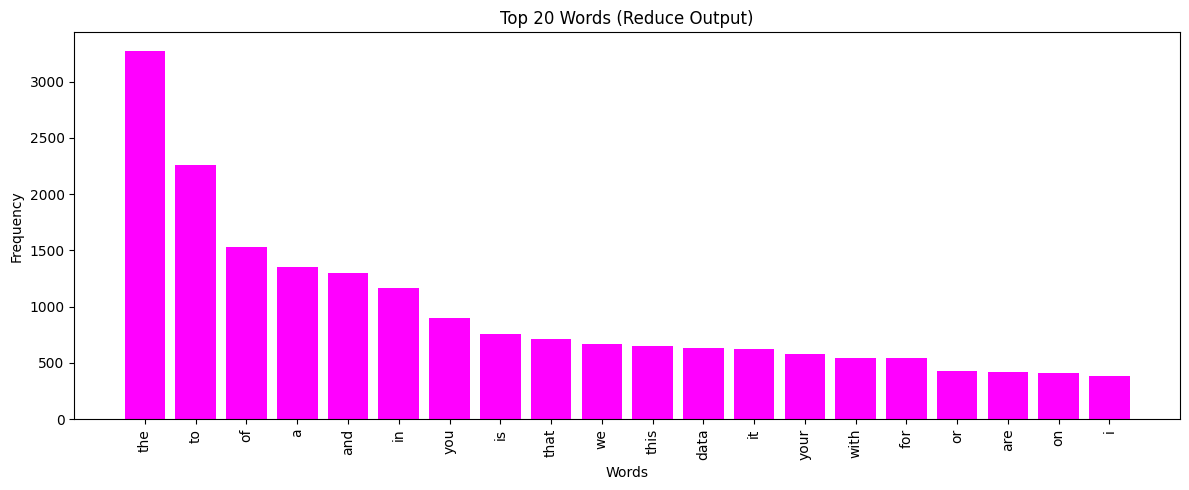

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.bar(words, counts,color='magenta')
plt.xticks(rotation=90)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Words (Reduce Output)")
plt.tight_layout()
plt.show()


**Map Phase:**

 TokenizationThe Mapper reads the cleaned text and breaks it into individual tokens (words). For every word it encounters, it emits a key-value pair where the key is the word and the value is $1$.

 **Logic:**
  Every word instance is treated as an independent emission.
  
  **Visualization:**
   The "Map Phase Histogram" shows these initial emissions, where common words like "the," "to," and "of" are identified for the first time.

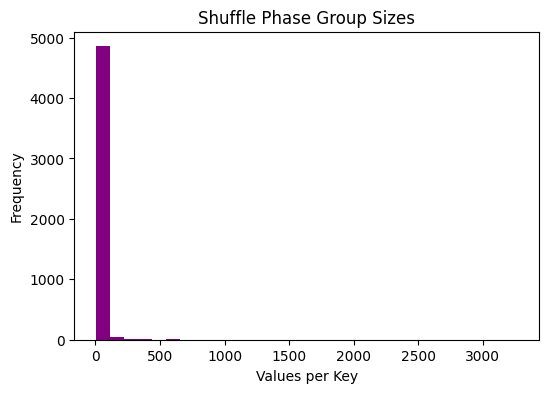

In [58]:
group_sizes = [len(v) for v in shuffle_output.values()]
plt.figure(figsize=(6,4))
plt.hist(group_sizes, bins=30,color='purple')
plt.title("Shuffle Phase Group Sizes")
plt.xlabel("Values per Key")
plt.ylabel("Frequency")
plt.show()


 **Shuffle & Sort Phase:**

 This phase is the "intermediate" step that prepares data for the Reducer. It moves all identical keys to the same node and groups their values.

 **Shuffling:** Hadoop gathers all instances of a word into a single list. For example, the word "a" is grouped with a list of over $1,300$ ones.

 **Sorting:** Keys are ordered alphabetically (e.g., "a" $\to$ "abbre" $\to$ "abc") to optimize processing speed.

 **Key Distribution:** Most words in the book appear only a few times, while a small subset of "stop words" forms very large groups.

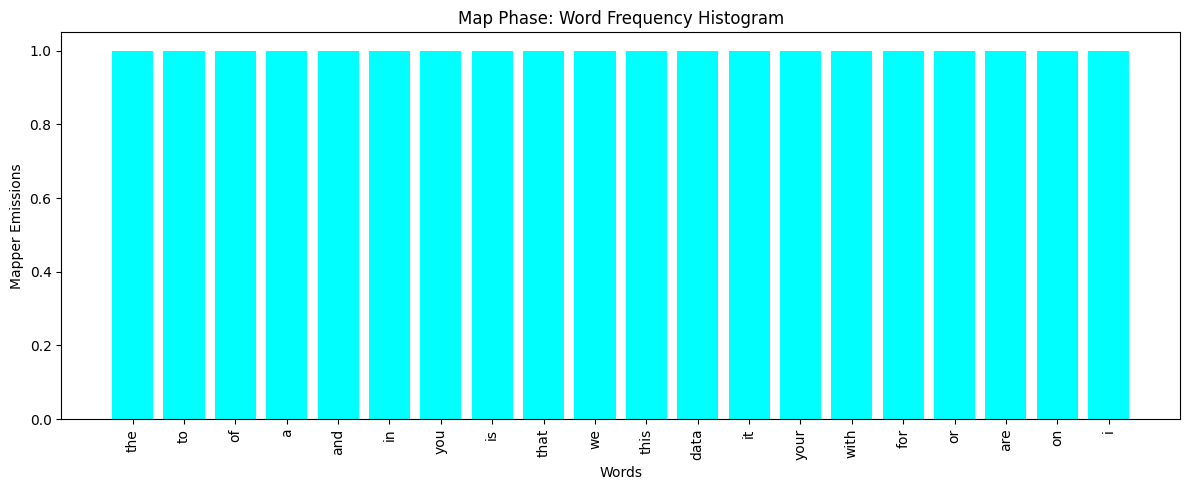

In [59]:
import matplotlib.pyplot as plt
from collections import Counter

# words list already created earlier
map_freq = Counter(words)

# Take top 30 mapper outputs
top_map = map_freq.most_common(30)
map_words, map_counts = zip(*top_map)

plt.figure(figsize=(12,5))
plt.bar(map_words, map_counts,color='cyan')
plt.xticks(rotation=90)
plt.xlabel("Words")
plt.ylabel("Mapper Emissions")
plt.title("Map Phase: Word Frequency Histogram")
plt.tight_layout()
plt.show()


**Reduce Phase:**

 The Reducer takes the grouped lists from the previous phase and performs a summation: $Count = \sum(1, 1, 1, ...)

 **Final Counts:**
  The lists of ones are collapsed into single totals.
  
  **Top Results:**
   The "Reduce Output" shows that "the" is the most frequent word ($3,274$), followed by "to" ($2,258$) and "of" ($1,527$).
   
   **Visual Insights:**
 The "Word Cloud" provides a quick look at the book's density, with "data," "figure," and "visual" appearing as significant non-stop words.

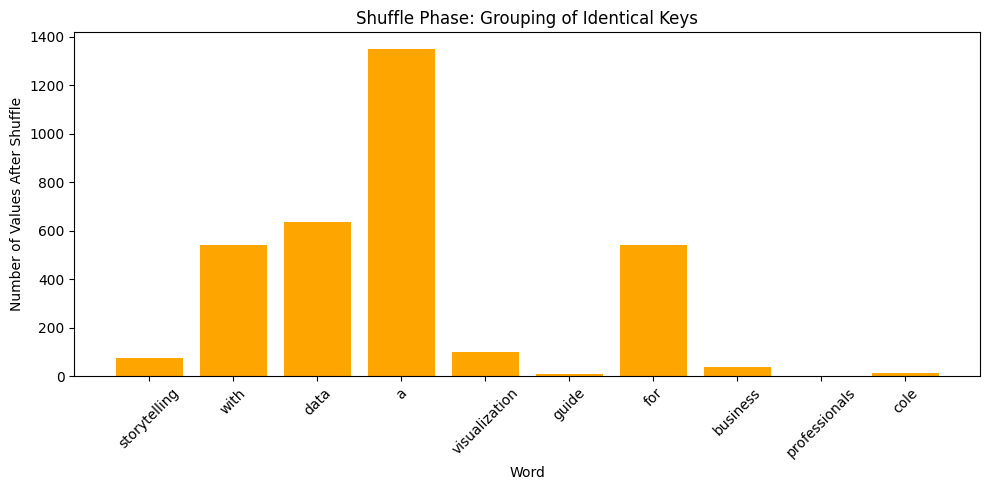

In [60]:
# Visualizing shuffle groups for first 10 words
sample_shuffle = list(shuffle_output.items())[:10]

words = [item[0] for item in sample_shuffle]
group_sizes = [len(item[1]) for item in sample_shuffle]

plt.figure(figsize=(10,5))
plt.bar(words, group_sizes,color='orange')
plt.xticks(rotation=45)
plt.xlabel("Word")
plt.ylabel("Number of Values After Shuffle")
plt.title("Shuffle Phase: Grouping of Identical Keys")
plt.tight_layout()
plt.show()


**Word -> Total Frequency**

the ->"3,274"

to ->"2,258"

of->"1,527"

a->"1,351"

and->"1,299"

in->"1,163"

you->896

is->753

that->708

we->669

In [61]:
!pip install wordcloud


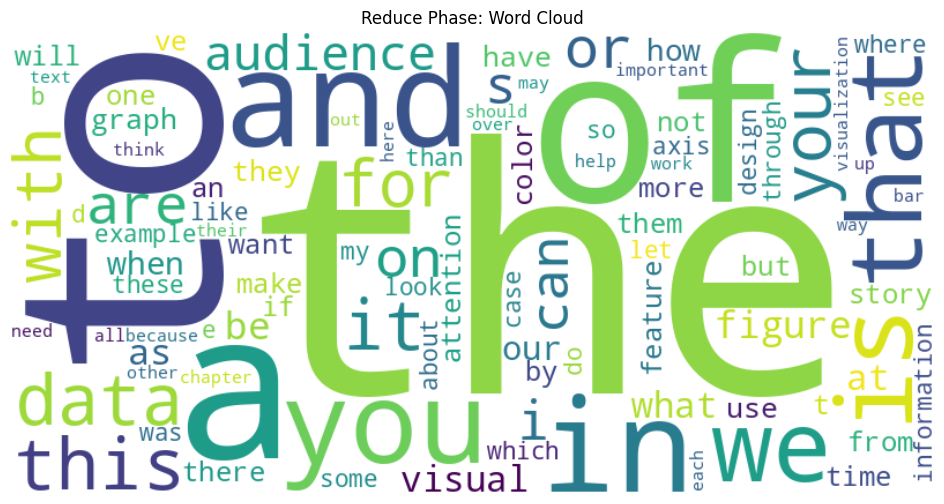

In [62]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate_from_frequencies(reduced_output)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Reduce Phase: Word Cloud")
plt.show()


**Output Phase:**

The final results are written as part-files (e.g., part-r-00000) to the output directory. This data is now ready for high-level business intelligence or further visualization.

##**Architecture Overview**

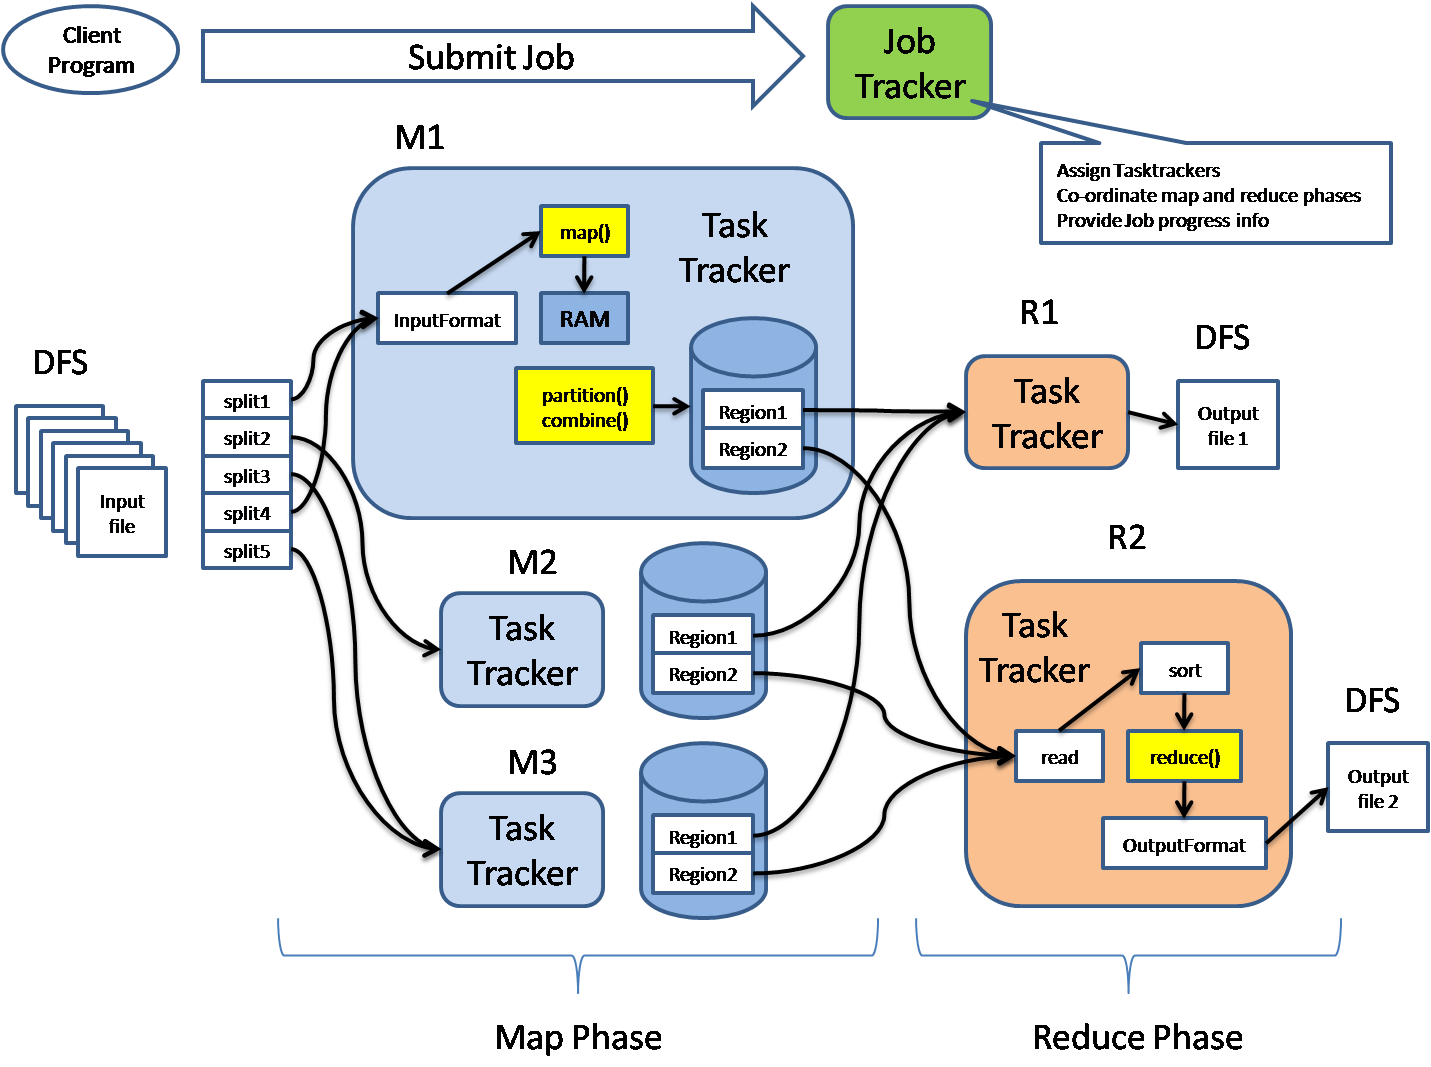

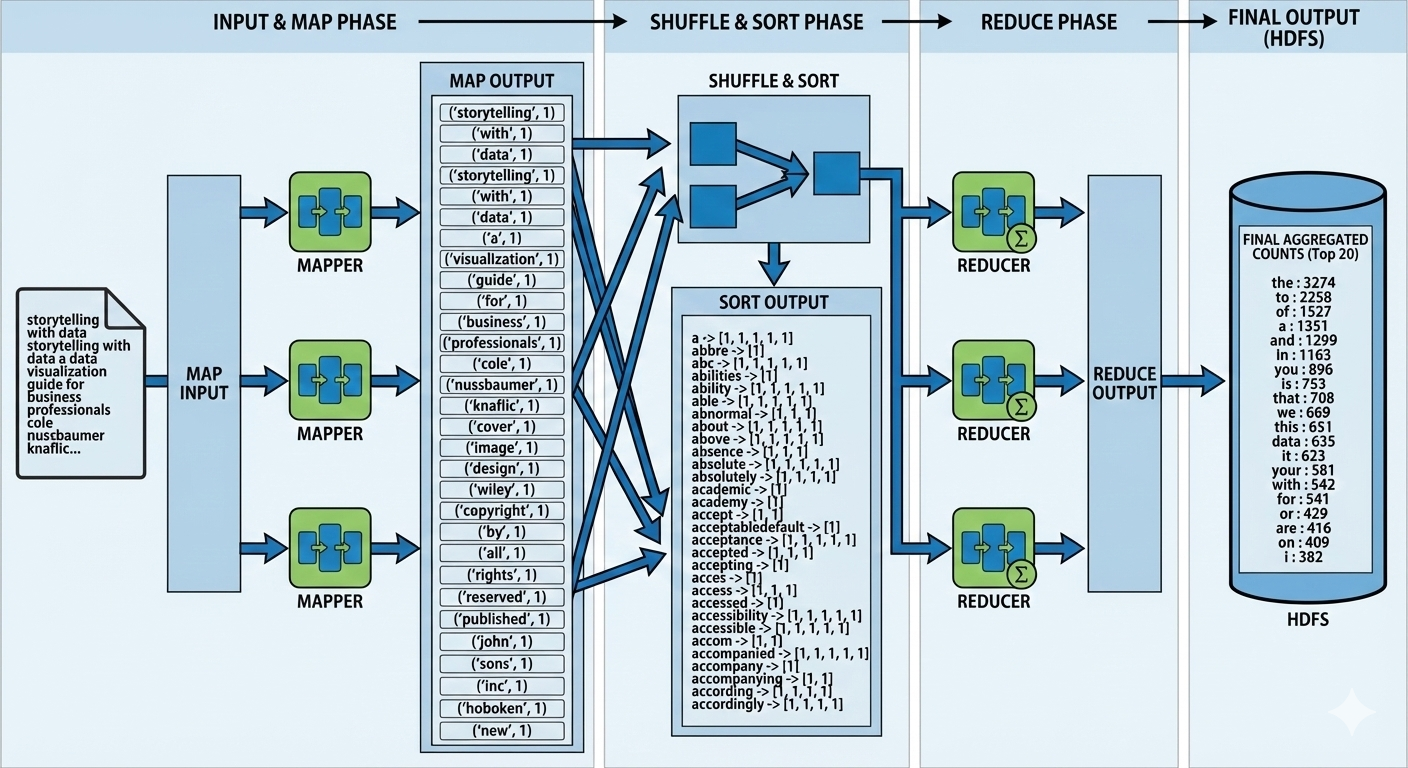